<a href="https://colab.research.google.com/github/thaovu31251021311-star/AI_Homework_23/blob/main/BT_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium
m=folium.Map(location=[10.783346274055639, 106.69462527972806],zoom_start=13)
places = [
    ("UEH cơ sở A", [10.783346274055639, 106.69462527972806]),
    ("Co.opmart Nguyễn Đình Chiểu", [10.78178644139167, 106.69243659725772]),
    ("Nhà Văn hóa Thanh Niên", [10.781839138573114, 106.69735040398032]),
    ("Bảo tàng Chứng tích Chiến tranh", [10.779762862610644, 106.69210400333432]),
    ("Nhà hát Thành phố Hồ Chí Minh", [10.776369121814731, 106.70317616198383])
]
for name, coord in places:
    folium.Marker(
        location=coord,
        popup=name,
        tooltip="Click vào"
    ).add_to(m)
m

In [ ]:
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

geolocator = Nominatim(user_agent="MAP_UEH")

addresses = [
    "UEH cơ sở A, Ho Chi Minh City, Vietnam",
    "Co.opmart Nguyễn Đình Chiểu, Ho Chi Minh City, Vietnam",
    "Bệnh viện Từ Dũ, Ho Chi Minh City, Vietnam",
    "Nhà Văn hóa Thanh Niên, Ho Chi Minh City, Vietnam",
    "Bảo tàng Chứng tích Chiến tranh, Ho Chi Minh City, Vietnam",
    "Nhà hát Thành phố Hồ Chí Minh, Vietnam",
    "Bưu điện trung tâm Sài Gòn, Ho Chi Minh City, Vietnam",
    "Vincom Center Đồng Khởi, Ho Chi Minh City, Vietnam",
    "Bệnh viện Nhi Đồng 2, Ho Chi Minh City, Vietnam",
    "Nhà Ga Ngầm Ba Son - Tôn Đức Thắng, Ho Chi Minh City, Vietnam",
    "Đường sách Thành phố Hồ Chí Minh, Ho Chi Minh City, Vietnam",
]

coords = []

for addr in addresses:
    location = geolocator.geocode(addr)
    time.sleep(1)

    if location is None:continue

    coord = (location.latitude, location.longitude)
    coords.append((addr, coord))

center_name, center_coord = coords[0]

m = folium.Map(location=center_coord, zoom_start=13)

folium.Marker(
    center_coord,
    popup=center_name,
    icon=folium.Icon(color="red")
).add_to(m)

for name, coord in coords[1:]:
        folium.Marker(
        coord,
        popup=name,
        icon=folium.Icon(color="blue")
    ).add_to(m)
        dist = geodesic(center_coord, coord).km

        folium.PolyLine(
            [center_coord, coord],
            color="green"
        ).add_to(m)

        mid_point = [
            (center_coord[0] + coord[0]) / 2,
            (center_coord[1] + coord[1]) / 2
        ]

        folium.Marker(
            location=mid_point,
            icon=folium.DivIcon(html=f"<b>{dist:.2f} km</b>")
        ).add_to(m)

m

In [ ]:
import folium
from folium.plugins import HeatMap
import random
center = [10.7769, 106.7009]
m = folium.Map(location=center, zoom_start=12)
heat_data = []
for _ in range(80):
    lat = 10.775 + random.uniform(-0.005, 0.005)
    lon = 106.700 + random.uniform(-0.005, 0.005)
    heat_data.append([lat, lon])
for _ in range(60):
    lat = 10.780 + random.uniform(-0.006, 0.006)
    lon = 106.685 + random.uniform(-0.006, 0.006)
    heat_data.append([lat, lon])
for _ in range(40):
    lat = 10.800 + random.uniform(-0.008, 0.008)
    lon = 106.710 + random.uniform(-0.008, 0.008)
    heat_data.append([lat, lon])
for _ in range(20):
    lat = 10.850 + random.uniform(-0.015, 0.015)
    lon = 106.780 + random.uniform(-0.015, 0.015)
    heat_data.append([lat, lon])
HeatMap(
    heat_data,
    radius=25,
    blur=20
).add_to(m)
m

**Giải thích ý nghĩa quản trị của các vùng nóng (đỏ) trên bản đồ:**

Bản độ nhiệt trên thể hiện sự phân bố dân cư ở các khu vực như Quận 1, Quận 3, Bình Thạnh và TP. Thủ Đức. Các vùng màu đỏ trên bản đồ nhiệt (Quận 1, 3) thể hiện khu vực có mật độ phân bố dân cư cao. Do đó, khu vực Quận 1 và Quận 3 là nơi nhu cầu tiêu dùng cao, phù hợp để phát triển kinh doanh, mở rộng thị trường hoặc cung cấp các địa điểm dịch vụ tại các điểm trong khu vực này.

Tuy nhiên, các khu vực mật độ cao sẽ đi kèm với áp lực hạ tầng, chi phí vận hành cao và mức độ cạnh tranh lớn. Do đó, địa điểm dịch vụ thuộc khu vực này luôn có chi phí đắt đỏ. Ngoài ra, các khu vực “đỏ” này cũng sẽ luôn xuất hiện với tình trạng kẹt xe kéo dài.


In [ ]:
import folium
import pandas as pd
import json
map = pd.read_csv("23_4.csv", encoding="utf-8-sig")
map = map.rename(columns={
    "Khu vuc": "Khu vực",
    " Dân số (người) ": "Dân số"
})
map["Khu vực"] = map["Khu vực"].str.replace("Quan", "Quận")
map["Khu vực"] = map["Khu vực"].str.strip()
with open("district-boundary-hcm-city.geojson", encoding="utf-8") as f:
    geo_data = json.load(f)
geo_data["features"] = [
    f for f in geo_data["features"]
    if f["properties"]["admin_level"] == 6
]
m = folium.Map(location=[10.78, 106.69], zoom_start=11)
folium.Choropleth(
    geo_data=geo_data,
    data=map,
    columns=["Khu vực", "Dân số"],
    key_on="feature.properties.localname",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Dân số",
    nan_fill_color="white"
).add_to(m)
m

**Giải thích:**

Bản đồ trên thể hiện sự phân bố dân số ở các Quận 1, Quận 3, Quận 4, Quận 5, Quận 7, Quận Bình Thạnh, Quận Phú Nhuận tại TP.HCM. Từ đây ta có thể thấy khu vực nào sẽ có mức tiêu thụ cao hơn cũng như xác định tiềm lực kinh tế của từng khu vực trên. Qua đó, ta sẽ xác định mình nên ưu tiên đầu tư vào khu vực nào.


In [ ]:
import folium

center = [10.808465106037367, 106.66268232397766]
m = folium.Map(location=center, zoom_start=13)

folium.Marker(
    location=center,
    popup="Kho Hàng Không TCS",
    icon=folium.Icon(color="red")
).add_to(m)

folium.Circle(
    location=center,
    radius=3000,
    color="red",
    fill=True,
    fill_opacity=0.2,
    popup="Vùng 3 km"
).add_to(m)

folium.Circle(
    location=center,
    radius=5000,
    color="orange",
    fill=True,
    fill_opacity=0.2,
    popup="Vùng 5 km"
).add_to(m)

folium.Circle(
    location=center,
    radius=10000,
    color="green",
    fill=True,
    fill_opacity=0.2,
    popup="Vùng 10 km"
).add_to(m)

m

**Phân tích các vùng phục vụ:**

*   ***Vùng 3km:*** phù hợp với các dịch vụ giao hàng nhanh với mức chi phí thấp.
*   ***Vùng 5km:*** có thể tiếp cận được nhiều khách hàng trong khi chi phí vận hành sẽ không tăng quá cao, đồng thời còn đảm bảo chất lượng dịch vụ ở mức hiệu quả. Do đó, đây sẽ là phạm vi phục vụ tương đối ổn nhất so với 2 vùng còn lại.
*   ***Vùng 10km:*** giúp tăng phủ sóng đến với khách hàng, song với đó là chi phí và thời gian phục vụ tăng cao.

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.1 MB/s eta 0:00:00


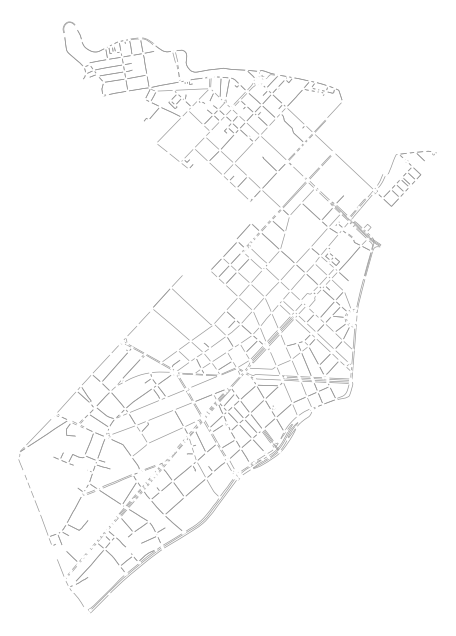

Số nút giao: 985
Số đoạn đường: 2081
Tổng chiều dài đường (m): 165018.51
Chiều dài trung bình (m): 79.3
Mật độ mạng (m/m²): 0.02055330871569494


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
fig, ax = ox.plot_graph(
    G,
    node_size=5,
    edge_linewidth=0.5,
    bgcolor="white"
)
num_nodes = len(G.nodes)
print("Số nút giao:", num_nodes)
num_edges = len(G.edges)
print("Số đoạn đường:", num_edges)
edges = ox.graph_to_gdfs(G, nodes=False)
total_length = edges["length"].sum()
print("Tổng chiều dài đường (m):", round(total_length, 2))
avg_length = edges["length"].mean()
print("Chiều dài trung bình (m):", round(avg_length, 2))
area_gdf = ox.geocode_to_gdf(place_name)
area_gdf = area_gdf.to_crs(epsg=3857)
area = area_gdf.area.values[0]
density = total_length / area
print("Mật độ mạng (m/m²):", density)

In [ ]:
import osmnx as ox
import networkx as nx
import folium

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

origin = (10.7819, 106.6974)   # Nhà Văn hóa Thanh Niên
destination = (10.7727, 106.6980)  # Chợ Bến Thành

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight='length')

def heuristic(u, v):
    y1, x1 = G.nodes[u]['y'], G.nodes[u]['x']
    y2, x2 = G.nodes[v]['y'], G.nodes[v]['x']
    return ((x1 - x2)**2 + (y1 - y2)**2) ** 0.5

route_astar = nx.astar_path(G, orig_node, dest_node, heuristic=heuristic, weight='length')

orig_point = (G.nodes[orig_node]['y'], G.nodes[orig_node]['x'])
dest_point = (G.nodes[dest_node]['y'], G.nodes[dest_node]['x'])

m = folium.Map(location=origin, zoom_start=14)

folium.PolyLine(
    locations=[(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_dijkstra],
    color='blue',
    weight=6,
    opacity=0.5,
    tooltip='Dijkstra'
).add_to(m)

folium.PolyLine(
    locations=[(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_astar],
    color='red',
    weight=3,
    tooltip='A*'
).add_to(m)

folium.Marker(orig_point, popup="Nhà Văn hoá Thanh niên TP. Hồ Chí Minh").add_to(m)
folium.Marker(dest_point, popup="Chợ Bến Thành").add_to(m)

m

**Phân tích ưu – nhược điểm của từng phương pháp:**
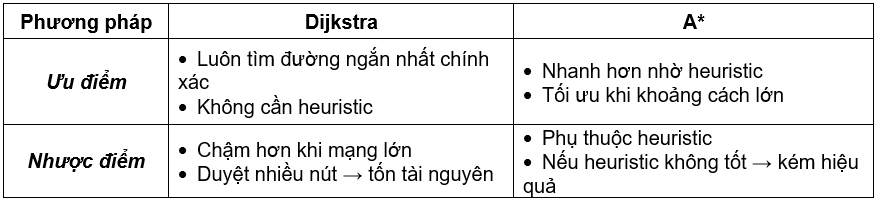

In [ ]:
import folium
import osmnx as ox
import numpy as np
from geopy.distance import geodesic
from scipy.optimize import linear_sum_assignment

center = (10.7769, 106.7009)
m = folium.Map(location=center, zoom_start=14)

drivers = [
    (10.781383774070653, 106.69666483426806),
    (10.787066319951808, 106.69628451117019),
    (10.779836864429704, 106.70141188253703),
    (10.781561559004665, 106.69494778152743)
]
customers = [
    (10.783676859871798, 106.69810238128417),
    (10.786100905457765, 106.69226589469582),
    (10.78367685989812, 106.69458332319383),
    (10.777311012422988, 106.69531288399119)
]

cost_matrix = np.zeros((len(customers), len(drivers)))

for i, c in enumerate(customers):
    for j, d in enumerate(drivers):
        cost_matrix[i][j] = geodesic(c, d).km
row_ind, col_ind = linear_sum_assignment(cost_matrix)

G = ox.graph_from_point(center, dist=3000, network_type='drive')

colors = ['red', 'blue', 'green', 'purple', 'orange']

for idx, (i, j) in enumerate(zip(row_ind, col_ind)):
    c = customers[i]
    d = drivers[j]
    try:
        orig_node = ox.distance.nearest_nodes(G, d[1], d[0])
        dest_node = ox.distance.nearest_nodes(G, c[1], c[0])
        orig_point = (G.nodes[orig_node]['y'], G.nodes[orig_node]['x'])
        dest_point = (G.nodes[dest_node]['y'], G.nodes[dest_node]['x'])

        folium.Marker(
            orig_point,
            popup=f"Driver {j}",
            icon=folium.Icon(color='blue')
        ).add_to(m)
        folium.Marker(
            dest_point,
            popup=f"Customer {i}",
            icon=folium.Icon(color='red')
        ).add_to(m)
        route = ox.shortest_path(G, orig_node, dest_node, weight='length')
        folium.PolyLine(
            [(G.nodes[n]['y'] + idx*0.00005,
              G.nodes[n]['x'] + idx*0.00005) for n in route],
            color=colors[idx % len(colors)],
            weight=4,
            tooltip=f"Driver {j} → Customer {i} ({cost_matrix[i][j]:.2f} km)"
        ).add_to(m)

    except Exception as e:
        print("Lỗi route:", e)
m

In [ ]:
import folium
import osmnx as ox
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="call_driver")

center = (10.7769, 106.7009)
m = folium.Map(location=center, zoom_start=14)

drivers = [
    {"id": 0, "coord": (10.7813, 106.6966), "available": True},
    {"id": 1, "coord": (10.7870, 106.6962), "available": True},
    {"id": 2, "coord": (10.7798, 106.7014), "available": True},
    {"id": 3, "coord": (10.7815, 106.6949), "available": True}
]

G = ox.graph_from_point(center, dist=3000, network_type='drive')

colors = ['red', 'blue', 'green', 'purple']

for idx in range(4):

    address = input(f"Nhập địa chỉ khách hàng {idx+1}: ")

    location = geolocator.geocode(address)

    if location is None:
        print("❌ Không tìm thấy địa chỉ, thử lại!")
        continue

    customer_coord = (location.latitude, location.longitude)

    min_dist = float("inf")
    chosen_driver = None

    for d in drivers:
        if d["available"]:
            dist = geodesic(customer_coord, d["coord"]).km
            if dist < min_dist:
                min_dist = dist
                chosen_driver = d

    if chosen_driver is None:
        print("❌ Hết xe rồi!")
        break

    chosen_driver["available"] = False

    try:
        orig_node = ox.distance.nearest_nodes(G, chosen_driver["coord"][1], chosen_driver["coord"][0])
        dest_node = ox.distance.nearest_nodes(G, customer_coord[1], customer_coord[0])

        route = ox.shortest_path(G, orig_node, dest_node, weight='length')

        route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

        orig_point = (G.nodes[orig_node]['y'], G.nodes[orig_node]['x'])
        dest_point = (G.nodes[dest_node]['y'], G.nodes[dest_node]['x'])

        folium.Marker(orig_point, popup=f"Driver {chosen_driver['id']}", icon=folium.Icon(color='blue')).add_to(m)
        folium.Marker(dest_point, popup=f"Customer {idx+1}", icon=folium.Icon(color='red')).add_to(m)

        folium.PolyLine(
            route_coords,
            color=colors[idx % len(colors)],
            weight=5,
            tooltip=f"Driver {chosen_driver['id']} → Customer {idx+1} ({min_dist:.2f} km)"
        ).add_to(m)

        print(f"✅ Gán Driver {chosen_driver['id']} cho khách {idx+1} (≈ {min_dist:.2f} km)")

    except Exception as e:
        print("Lỗi route:", e)

m

Nhập địa chỉ khách hàng 1: Nhà thờ Đức Bà Sài Gòn
✅ Gán Driver 2 cho khách 1 (≈ 0.26 km)
Nhập địa chỉ khách hàng 2: Dinh Doc Lap Ho Chi Minh City
✅ Gán Driver 0 cho khách 2 (≈ 0.49 km)
Nhập địa chỉ khách hàng 3: Bao tang Chung tich Chien tranh Ho Chi Minh City
✅ Gán Driver 3 cho khách 3 (≈ 0.37 km)
Nhập địa chỉ khách hàng 4: Duong sach Ho Chi Minh City
✅ Gán Driver 1 cho khách 4 (≈ 0.81 km)


In [ ]:
!pip install osmnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
import folium
import random
import numpy as np
from sklearn.cluster import KMeans
cluster1 = [(10.78 + random.uniform(-0.005, 0.005),
             106.69 + random.uniform(-0.005, 0.005)) for _ in range(10)]
cluster2 = [(10.76 + random.uniform(-0.005, 0.005),
             106.71 + random.uniform(-0.005, 0.005)) for _ in range(10)]
cluster3 = [(10.80 + random.uniform(-0.005, 0.005),
             106.72 + random.uniform(-0.005, 0.005)) for _ in range(10)]
customers = cluster1 + cluster2 + cluster3
X = np.array(customers)
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
m = folium.Map(location=(10.7769, 106.7009), zoom_start=13)
colors = ['red', 'blue', 'green']
for i, coord in enumerate(customers):
    folium.CircleMarker(
        location=coord,
        radius=5,
        color=colors[labels[i]],
        fill=True
    ).add_to(m)
for idx, c in enumerate(centroids):
    folium.Marker(
        location=(c[0], c[1]),
        popup=f"Kho {idx}",
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(m)
m

**Giải thích:**
Vị trí đặt kho hàng là điểm có tổng khoảng cách ngắn nhất đến tất cả các khách hàng có trong cụm đó. Điều này sẽ giúp trạm kho hàng tối ưu hóa được chi phí vận chuyển cũng như thời gian di chuyển. Do đó, các trạm kho sẽ được tối đa hóa lợi nhuận và đảm bảo các đơn hàng có thể giao nhanh chóng tới tay khách hàng, nâng cao chất lượng dịch vụ.


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import folium
import osmnx as ox
import networkx as nx

df = pd.read_csv("/content/Ket.csv")
df.columns = df.columns.str.strip()

df['traffic'] = df['Traffic'].map({'Yes': 5, 'No': 1})

center = (df['lat'].mean(), df['lon'].mean())
m = folium.Map(location=center, zoom_start=14)

for _, row in df.iterrows():
    color = "red" if row['traffic'] == 5 else "green"

    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=6,
        color=color,
        fill=True,
        popup=row['Dia diem']
    ).add_to(m)

    if row['traffic'] == 5:
        folium.Circle(
            location=(row['lat'], row['lon']),
            radius=50,
            color='red',
            fill=True,
            fill_opacity=0.2
        ).add_to(m)

G = ox.graph_from_point(center, dist=4000, network_type='drive')

for u, v, k, data in G.edges(keys=True, data=True):
    base = data.get("length", 1)
    data["cost"] = base

    for _, row in df.iterrows():
        if row['traffic'] == 5:
            dist = abs(G.nodes[u]['y'] - row['lat']) + abs(G.nodes[u]['x'] - row['lon'])

            if dist < 0.005:
                data["cost"] = base * 25

origin = (10.801763788379256, 106.6525736659649)
destination = (10.79109354143604, 106.65247732431874)

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

orig_point = (G.nodes[orig_node]['y'], G.nodes[orig_node]['x'])
dest_point = (G.nodes[dest_node]['y'], G.nodes[dest_node]['x'])

route_short = nx.shortest_path(G, orig_node, dest_node, weight='length')
route_avoid = nx.shortest_path(G, orig_node, dest_node, weight='cost')

folium.PolyLine(
    [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_short],
    color='red',
    weight=5,
    opacity=0.6,
    tooltip='Shortest (có thể kẹt)'
).add_to(m)

folium.PolyLine(
    [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_avoid],
    color='green',
    weight=3,
    tooltip='Tuyến đề xuất (né kẹt)'
).add_to(m)

folium.Marker(orig_point, popup="Start").add_to(m)
folium.Marker(dest_point, popup="End").add_to(m)

m

In [ ]:
import pandas as pd
import folium
from sklearn.linear_model import LinearRegression
df = pd.read_csv("demand_data.csv")
df.columns = df.columns.str.strip()
X = df[['lat', 'lon', 'hour']]
y = df['demand']
model = LinearRegression()
model.fit(X, y)
hour_input = int(input("Nhập giờ (0-23): "))
df_pred = df.copy()
df_pred['hour'] = hour_input
df_pred['predicted_demand'] = model.predict(df_pred[['lat', 'lon', 'hour']])
center = (df['lat'].mean(), df['lon'].mean())
m = folium.Map(location=center, zoom_start=12)
for _, row in df_pred.iterrows():
    if row['predicted_demand'] > 70:
        color = 'red'
    elif row['predicted_demand'] > 50:
        color = 'orange'
    else:
        color = 'green'
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=6,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Hour: {hour_input} | Demand: {row['predicted_demand']:.0f}"
    ).add_to(m)
m

Nhập giờ (0-23): 10


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import folium
import osmnx as ox
import networkx as nx
import numpy as np
df = pd.read_csv("vrp_data.csv")
df.columns = df.columns.str.strip()
depots = df[df['type'] == 'depot']
customers = df[df['type'] == 'customer']
center = (df['lat'].mean(), df['lon'].mean())
m = folium.Map(location=center, zoom_start=13)
G = ox.graph_from_point(center, dist=5000, network_type='drive')
def snap_point(lat, lon):
    node = ox.distance.nearest_nodes(G, lon, lat)
    return node, (G.nodes[node]['y'], G.nodes[node]['x'])
depot_nodes = {}
for idx, d in depots.iterrows():
    node, point = snap_point(d['lat'], d['lon'])
    depot_nodes[idx] = (node, point)
customer_nodes = {}
for idx, c in customers.iterrows():
    node, point = snap_point(c['lat'], c['lon'])
    customer_nodes[idx] = (node, point)
assignments = {}
for c_idx, (c_node, c_point) in customer_nodes.items():
    min_dist = float('inf')
    best_depot = None
    for d_idx, (d_node, d_point) in depot_nodes.items():
        dist = np.sqrt((c_point[0] - d_point[0])**2 + (c_point[1] - d_point[1])**2)
        if dist < min_dist:
            min_dist = dist
            best_depot = d_idx
    assignments[c_idx] = best_depot
def get_route(node1, node2):
    route = nx.shortest_path(G, node1, node2, weight='length')
    return [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
colors = ['blue', 'green', 'yellow']
for idx, (node, point) in depot_nodes.items():
    folium.Marker(
        point,
        icon=folium.Icon(color='black'),
        popup=f"Depot {idx}"
    ).add_to(m)
for idx, (node, point) in customer_nodes.items():
    folium.CircleMarker(
        point,
        radius=6,
        color='red',
        fill=True,
        popup=f"Customer {idx}"
    ).add_to(m)
total_random = 0
for depot_idx, (d_node, d_point) in depot_nodes.items():
    cust_list = [c for c, d in assignments.items() if d == depot_idx]
    if not cust_list:
        continue
    current_node = d_node
    for c_idx in cust_list:
        next_node, next_point = customer_nodes[c_idx]
        route = get_route(current_node, next_node)
        folium.PolyLine(route, color='gray', weight=2, opacity=0.5).add_to(m)
        total_random += len(route)
        current_node = next_node
total_opt = 0
for depot_idx, (d_node, d_point) in depot_nodes.items():
    cust_list = [c for c, d in assignments.items() if d == depot_idx]
    if not cust_list:
        continue
    unvisited = cust_list.copy()
    current_node = d_node
    color = colors[list(depot_nodes.keys()).index(depot_idx)]
    while unvisited:
        next_cust = min(
            unvisited,
            key=lambda c: nx.shortest_path_length(
                G,
                current_node,
                customer_nodes[c][0],
                weight='length'
            )
        )
        next_node, next_point = customer_nodes[next_cust]
        route = get_route(current_node, next_node)
        folium.PolyLine(route, color=color, weight=4).add_to(m)
        total_opt += len(route)
        current_node = next_node
        unvisited.remove(next_cust)
m

In [ ]:
import folium
import pandas as pd
from IPython.display import display
points_data = {
    "id":     ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10"],
    "name":   ["Ben Thanh Market","Saigon Centre","Customer A","Customer B",
                "Customer C","Warehouse A","Warehouse B","Hospital D1","School A","Shop Center"],
    "lat":    [10.7758,10.7735,10.762,10.751,10.768,10.7769,10.79,10.779,10.767,10.772],
    "lon":    [106.7009,106.701,106.682,106.674,106.708,106.7009,106.71,106.704,106.695,106.712],
    "type":   ["poi","poi","customer","customer","customer","warehouse","warehouse","poi","poi","shop"],
    "value":  [100,90,50,40,70,200,180,120,60,85],
    "region": ["D1","D1","D1","D1","D2","D1","D2","D1","D1","D2"],
}
metrics_data = {
    "id":               ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10"],
    "sales":            [1200,900,600,500,700,3000,2500,400,450,800],
    "demand":           [80,60,75,50,65,0,0,30,25,40],
    "traffic_score":    [0.7,0.5,0.8,0.6,0.9,0.4,0.3,0.5,0.4,0.6],
    "risk_level":       ["low","low","medium","medium","high","low","low","low","low","medium"],
    "delivery_time_min":[5,4,10,12,9,0,0,6,7,8],
    "service_quality":  [0.9,0.85,0.7,0.65,0.8,1.0,1.0,0.88,0.86,0.82],
}
routes_data = {
    "route_id":    ["R1","R2","R3","R4","R5","R6","R7","R8","R9","R10"],
    "from_id":     ["P6","P6","P6","P7","P7","P6","P6","P3","P2","P9"],
    "to_id":       ["P3","P4","P5","P5","P10","P1","P2","P4","P1","P8"],
    "distance_km": [2.6,4.1,1.3,2.0,1.8,1.2,1.0,2.2,0.5,1.4],
    "duration_min":[8,12,5,7,6,4,3,7,2,5],
    "type":        ["delivery","delivery","delivery","delivery","delivery",
                    "transport","transport","customer_link","walk","service"],
}
df_points  = pd.DataFrame(points_data)
df_metrics = pd.DataFrame(metrics_data)
df_routes  = pd.DataFrame(routes_data)
df = df_points.merge(df_metrics, on="id")
pt_lookup = df.set_index("id").to_dict("index")
print("✅ Data loaded!")
print(f"   📍 Points  : {len(df_points)} điểm")
print(f"   🛣️  Routes  : {len(df_routes)} tuyến")
print(f"   📊 Metrics : {len(df_metrics)} bản ghi")
TYPE_COLOR = {
    "poi"      : "orange",
    "warehouse": "green",
    "customer" : "red",
    "shop"     : "purple",
}
TYPE_ICON = {
    "poi"      : "info-sign",
    "warehouse": "home",
    "customer" : "user",
    "shop"     : "shopping-cart",
}
ROUTE_COLOR = {
    "delivery"     : "#00cc88",
    "transport"    : "#f59e0b",
    "customer_link": "#ef4444",
    "walk"         : "#94a3b8",
    "service"      : "#a78bfa",
}
RISK_COLOR = {
    "low"   : "🟢",
    "medium": "🟡",
    "high"  : "🔴",
}
m = folium.Map(
    location=[10.772, 106.698],
    zoom_start=14,
    tiles="CartoDB dark_matter",
)
layer_points = folium.FeatureGroup(name="📍 Địa điểm", show=True)
layer_routes = folium.FeatureGroup(name="🛣️ Tuyến đường", show=True)
layer_zones  = folium.FeatureGroup(name="🗺️ Vùng khu vực", show=True)
zone_coords = {
    "D1 - District 1": [
        [10.7731, 106.7000], [10.7780, 106.7050],
        [10.7770, 106.7100], [10.7650, 106.6950],
    ],
    "D2 - District 2": [
        [10.7900, 106.7200], [10.7950, 106.7150],
        [10.7850, 106.7300], [10.7800, 106.7250],
    ],
}
zone_colors = {"D1 - District 1": "#f59e0b", "D2 - District 2": "#00d4aa"}
for zone_name, coords in zone_coords.items():
    folium.Polygon(
        locations=coords,
        color=zone_colors[zone_name],
        fill=True,
        fill_opacity=0.12,
        weight=2,
        dash_array="6 4",
        tooltip=zone_name,
    ).add_to(layer_zones)
for _, r in df_routes.iterrows():
    fp = pt_lookup.get(r["from_id"])
    tp = pt_lookup.get(r["to_id"])
    if not fp or not tp:
        continue
    color = ROUTE_COLOR.get(r["type"], "#888")
    dash  = "5 5" if r["type"] in ["walk","customer_link"] else None
    folium.PolyLine(
        locations=[[fp["lat"], fp["lon"]], [tp["lat"], tp["lon"]]],
        color=color,
        weight=3,
        opacity=0.85,
        dash_array=dash,
        tooltip=f"{r['route_id']}: {fp['name']} → {tp['name']} | {r['distance_km']} km | {r['duration_min']} phút",
    ).add_to(layer_routes)
for _, row in df.iterrows():
    color = TYPE_COLOR.get(row["type"], "gray")
    icon  = TYPE_ICON.get(row["type"], "info-sign")
    risk  = RISK_COLOR.get(row["risk_level"], "⚪")
    popup_html = f"""
    <div style="font-family:sans-serif;min-width:200px">
      <h4 style="margin:0 0 8px;color:#333">{row['name']}</h4>
      <table style="font-size:13px;width:100%;border-collapse:collapse">
        <tr><td style="color:#888">Loại</td><td><b>{row['type'].upper()}</b></td></tr>
        <tr><td style="color:#888">Vùng</td><td>{row['region']}</td></tr>
        <tr><td style="color:#888">Doanh thu</td><td><b>{row['sales']:,}</b></td></tr>
        <tr><td style="color:#888">Nhu cầu</td><td>{row['demand']}</td></tr>
        <tr><td style="color:#888">Rủi ro</td><td>{risk} {row['risk_level'].upper()}</td></tr>
        <tr><td style="color:#888">Traffic</td><td>{int(row['traffic_score']*100)}%</td></tr>
        <tr><td style="color:#888">T/g giao hàng</td><td>{row['delivery_time_min']} phút</td></tr>
        <tr><td style="color:#888">Chất lượng DV</td><td>{int(row['service_quality']*100)}%</td></tr>
      </table>
    </div>
    """
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['name']} | Sales: {row['sales']:,} | {risk}",
        icon=folium.Icon(color=color, icon=icon, prefix="glyphicon"),
    ).add_to(layer_points)
layer_zones.add_to(m)
layer_routes.add_to(m)
layer_points.add_to(m)
folium.LayerControl(position="topright", collapsed=False).add_to(m)
title_html = """
<div style="position:fixed;top:12px;left:12px;z-index:9999;
     background:rgba(0,0,0,0.75);color:white;padding:10px 16px;
     border-radius:8px;border-left:4px solid #00cc88;font-family:sans-serif">
  <div style="font-size:16px;font-weight:700;letter-spacing:1px">
      🗺️ GEO DASHBOARD
  </div>
  <div style="font-size:11px;color:#aaa;margin-top:2px">Quận 1 — TP. Hồ Chí Minh</div>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))
legend_html = """
<div style="position:fixed;bottom:24px;left:12px;z-index:9999;
     background:rgba(0,0,0,0.75);color:white;padding:12px 16px;
     border-radius:8px;font-family:sans-serif;font-size:12px">
  <b style="font-size:13px">Chú giải</b><br><br>
  <b>Điểm:</b><br>
  🟠 POI &nbsp; 🟢 Kho &nbsp; 🔴 Khách hàng &nbsp; 🟣 Cửa hàng<br><br>
  <b>Tuyến đường:</b><br>
  <span style="color:#00cc88">━━</span> Giao hàng &nbsp;
  <span style="color:#f59e0b">━━</span> Vận chuyển<br>
  <span style="color:#ef4444">╌╌</span> Khách hàng &nbsp;
  <span style="color:#a78bfa">━━</span> Dịch vụ &nbsp;
  <span style="color:#94a3b8">╌╌</span> Đi bộ
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
print("\n" + "="*50)
print("📊 THỐNG KÊ TỔNG QUAN")
print("="*50)
print(f"{'Tổng địa điểm':<25}: {len(df)} điểm")
print(f"{'Tổng tuyến đường':<25}: {len(df_routes)} tuyến")
print(f"{'Tổng doanh thu':<25}: {df['sales'].sum():,}")
print(f"{'Doanh thu TB/điểm':<25}: {df['sales'].mean():,.0f}")
print(f"{'Điểm rủi ro cao':<25}: {(df['risk_level']=='high').sum()} điểm")
print(f"{'Điểm rủi ro TB':<25}: {(df['risk_level']=='medium').sum()} điểm")
print("\n📍 Top 3 doanh thu:")
print(df[["name","type","sales","risk_level"]]
      .sort_values("sales", ascending=False)
      .head(3)
      .to_string(index=False))
print("\n🛣️ Tuyến dài nhất:")
print(df_routes.sort_values("distance_km", ascending=False)
      .head(3)[["route_id","from_id","to_id","distance_km","type"]]
      .to_string(index=False))
print("\n✅ Bản đồ đã sẵn sàng!")
display(m)

✅ Data loaded!
   📍 Points  : 10 điểm
   🛣️  Routes  : 10 tuyến
   📊 Metrics : 10 bản ghi

📊 THỐNG KÊ TỔNG QUAN
Tổng địa điểm            : 10 điểm
Tổng tuyến đường         : 10 tuyến
Tổng doanh thu           : 11,050
Doanh thu TB/điểm        : 1,105
Điểm rủi ro cao          : 1 điểm
Điểm rủi ro TB           : 3 điểm

📍 Top 3 doanh thu:
            name      type  sales risk_level
     Warehouse A warehouse   3000        low
     Warehouse B warehouse   2500        low
Ben Thanh Market       poi   1200        low

🛣️ Tuyến dài nhất:
route_id from_id to_id  distance_km          type
      R2      P6    P4          4.1      delivery
      R1      P6    P3          2.6      delivery
      R8      P3    P4          2.2 customer_link

✅ Bản đồ đã sẵn sàng!


In [ ]:
import folium
import pandas as pd
import numpy as np
import time
import math
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets
POINTS = {
    "P1" : {"name": "Ben Thanh Market",  "lat": 10.7758, "lon": 106.7009, "type": "poi"},
    "P2" : {"name": "Saigon Centre",     "lat": 10.7735, "lon": 106.7010, "type": "poi"},
    "P3" : {"name": "Customer A",        "lat": 10.7620, "lon": 106.6820, "type": "customer"},
    "P4" : {"name": "Customer B",        "lat": 10.7510, "lon": 106.6740, "type": "customer"},
    "P5" : {"name": "Customer C",        "lat": 10.7680, "lon": 106.7080, "type": "customer"},
    "P6" : {"name": "Warehouse A",       "lat": 10.7769, "lon": 106.7009, "type": "warehouse"},
    "P7" : {"name": "Warehouse B",       "lat": 10.7900, "lon": 106.7100, "type": "warehouse"},
    "P8" : {"name": "Hospital D1",       "lat": 10.7790, "lon": 106.7040, "type": "poi"},
    "P9" : {"name": "School A",          "lat": 10.7670, "lon": 106.6950, "type": "poi"},
    "P10": {"name": "Shop Center",       "lat": 10.7720, "lon": 106.7120, "type": "shop"},
}
df_vehicles = pd.DataFrame({
    "vehicle_id":  ["V1",  "V2",  "V3",  "V4"],
    "start_point": ["P6",  "P7",  "P6",  "P7"],
    "end_point":   ["P3",  "P5",  "P4",  "P10"],
    "speed":       [0.05,  0.04,  0.03,  0.02],
    "status":      ["delivering", "delivering", "delivering", "delivering"],
})
print("📋 Vehicles:")
print(df_vehicles.to_string(index=False))
VEHICLE_COLORS = {
    "V1": "#00d4aa",
    "V2": "#f59e0b",
    "V3": "#ef4444",
    "V4": "#a78bfa",
}
VEHICLE_ICONS = {"V1": "🚚", "V2": "🚛", "V3": "🚐", "V4": "🚌"}
class Vehicle:
    def __init__(self, row):
        self.id         = row["vehicle_id"]
        self.start_id   = row["start_point"]
        self.end_id     = row["end_point"]
        self.speed      = row["speed"]
        self.status     = row["status"]
        self.progress   = 0.0
        self.color      = VEHICLE_COLORS.get(self.id, "#ffffff")
        self.icon       = VEHICLE_ICONS.get(self.id, "🚗")
        self.arrived    = False
        self.history    = []
        sp = POINTS[self.start_id]
        ep = POINTS[self.end_id]
        self.start_lat, self.start_lon = sp["lat"], sp["lon"]
        self.end_lat,   self.end_lon   = ep["lat"], ep["lon"]
        self.distance_km = self._haversine()
    def _haversine(self):
        """Tính khoảng cách thực tế (km) giữa 2 điểm."""
        R = 6371
        φ1, φ2 = math.radians(self.start_lat), math.radians(self.end_lat)
        Δφ = math.radians(self.end_lat - self.start_lat)
        Δλ = math.radians(self.end_lon  - self.start_lon)
        a = math.sin(Δφ/2)**2 + math.cos(φ1)*math.cos(φ2)*math.sin(Δλ/2)**2
        return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    def current_position(self):
        """Nội suy toạ độ hiện tại theo progress."""
        t = min(self.progress, 1.0)
        lat = self.start_lat + t * (self.end_lat - self.start_lat)
        lon = self.start_lon + t * (self.end_lon - self.start_lon)
        return lat, lon
    def step(self):
        """Cập nhật 1 bước thời gian."""
        if not self.arrived:
            self.progress = min(self.progress + self.speed, 1.0)
            lat, lon = self.current_position()
            self.history.append((lat, lon))
            if self.progress >= 1.0:
                self.arrived = True
                self.status  = "arrived"
    def pct(self):
        return int(self.progress * 100)
    def remaining_km(self):
        return round(self.distance_km * (1 - self.progress), 2)
def draw_map(vehicles, step_num, total_steps):
    m = folium.Map(
        location=[10.772, 106.698],
        zoom_start=14,
        tiles="CartoDB dark_matter",
    )
    type_color = {"poi": "orange", "warehouse": "green",
                  "customer": "red", "shop": "purple"}
    for pid, pt in POINTS.items():
        folium.CircleMarker(
            location=[pt["lat"], pt["lon"]],
            radius=6,
            color=type_color.get(pt["type"], "gray"),
            fill=True, fill_opacity=0.6, weight=2,
            tooltip=f"{pid}: {pt['name']}",
        ).add_to(m)
        folium.Marker(
            location=[pt["lat"], pt["lon"]],
            icon=folium.DivIcon(
                html=f'<div style="font-size:9px;color:#ccc;white-space:nowrap;'
                     f'margin-top:8px;margin-left:4px">{pt["name"]}</div>',
                icon_size=(120, 20), icon_anchor=(0, 0),
            )
        ).add_to(m)
    for v in vehicles:
        clr = v.color
        folium.PolyLine(
            locations=[[v.start_lat, v.start_lon], [v.end_lat, v.end_lon]],
            color=clr, weight=1.5, opacity=0.2, dash_array="6 4",
        ).add_to(m)
        if len(v.history) >= 2:
            folium.PolyLine(
                locations=v.history,
                color=clr, weight=3, opacity=0.9,
            ).add_to(m)
        lat, lon = v.current_position()
        status_emoji = "✅" if v.arrived else "🚀"
        popup_html = f"""
        <div style='font-family:sans-serif;min-width:180px'>
          <b style='font-size:14px'>{v.icon} {v.id}</b><br>
          <hr style='margin:4px 0'>
          <b>Trạng thái:</b> {status_emoji} {v.status}<br>
          <b>Từ:</b> {POINTS[v.start_id]['name']}<br>
          <b>Đến:</b> {POINTS[v.end_id]['name']}<br>
          <b>Tiến độ:</b> {v.pct()}%<br>
          <b>Còn lại:</b> {v.remaining_km()} km<br>
          <b>Tốc độ:</b> {v.speed*100:.0f}% / bước
        </div>
        """
        size = 18
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"{v.icon} {v.id} — {v.pct()}% | {v.remaining_km()} km còn lại",
            icon=folium.DivIcon(
                html=f'''<div style="
                    width:{size*2}px; height:{size*2}px;
                    border-radius:50%;
                    background:{clr};
                    border: 3px solid white;
                    display:flex; align-items:center; justify-content:center;
                    font-size:14px;
                    box-shadow: 0 0 12px {clr};
                    cursor:pointer;
                ">{v.icon}</div>''',
                icon_size=(size*2, size*2),
                icon_anchor=(size, size),
            ),
        ).add_to(m)
        if not v.arrived:
            folium.Marker(
                location=[v.end_lat, v.end_lon],
                icon=folium.DivIcon(
                    html=f'<div style="font-size:18px;color:{clr};'
                         f'text-shadow:0 0 6px {clr}">🎯</div>',
                    icon_size=(24, 24), icon_anchor=(12, 12),
                )
            ).add_to(m)
    arrived_count = sum(1 for v in vehicles if v.arrived)
    title_html = f"""
    <div style="position:fixed;top:10px;left:10px;z-index:9999;
         background:rgba(0,0,0,0.8);color:white;padding:10px 16px;
         border-radius:8px;border-left:4px solid #00cc88;font-family:sans-serif">
      <div style="font-size:15px;font-weight:700">🚚 VehicleSim — Quận 1</div>
      <div style="font-size:12px;color:#aaa">
        ⏱ Bước: <b style='color:#fff'>{step_num}</b> / {total_steps} &nbsp;|&nbsp;
        ✅ Đến nơi: <b style='color:#00cc88'>{arrived_count}</b> / {len(vehicles)}
      </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    rows = ""
    for v in vehicles:
        bar_w = v.pct()
        bar_c = "#00d4aa" if v.arrived else v.color
        rows += f"""
        <tr>
          <td>{v.icon} {v.id}</td>
          <td>
            <div style="background:#333;border-radius:4px;height:8px;width:100px">
              <div style="background:{bar_c};width:{bar_w}px;height:8px;border-radius:4px"></div>
            </div>
          </td>
          <td style="color:{bar_c};font-weight:bold">{v.pct()}%</td>
          <td style="color:#aaa">{v.remaining_km()}km</td>
        </tr>"""
    table_html = f"""
    <div style="position:fixed;bottom:20px;right:10px;z-index:9999;
         background:rgba(0,0,0,0.85);color:white;padding:12px 14px;
         border-radius:8px;font-family:sans-serif;font-size:12px">
      <b style="font-size:13px">📊 Trạng thái xe</b>
      <table style="margin-top:8px;border-collapse:collapse">
        <tr style="color:#888"><th>Xe</th><th>Tiến độ</th><th>%</th><th>Còn</th></tr>
        {rows}
      </table>
    </div>"""
    m.get_root().html.add_child(folium.Element(table_html))
    legend_html = """
    <div style="position:fixed;bottom:20px;left:10px;z-index:9999;
         background:rgba(0,0,0,0.8);color:white;padding:10px 14px;
         border-radius:8px;font-family:sans-serif;font-size:11px">
      <b>Chú giải điểm</b><br>
      🟠 POI &nbsp; 🟢 Kho &nbsp; 🔴 Khách hàng &nbsp; 🟣 Shop<br><br>
      <b>Xe</b><br>
      🚚 V1 &nbsp; 🚛 V2 &nbsp; 🚐 V3 &nbsp; 🚌 V4
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))
    return m
TOTAL_STEPS = 25
DELAY       = 1.2
vehicles = [Vehicle(row) for _, row in df_vehicles.iterrows()]
print("=" * 55)
print("  🚀 BẮT ĐẦU MÔ PHỎNG")
print(f"  Tổng bước: {TOTAL_STEPS} | Delay: {DELAY}s / bước")
print("=" * 55)
for step in range(1, TOTAL_STEPS + 1):
    for v in vehicles:
        v.step()
    clear_output(wait=True)
    print(f"\n⏱  BƯỚC {step:02d} / {TOTAL_STEPS}")
    print("-" * 50)
    for v in vehicles:
        bar = "█" * v.pct() + "░" * (100 - v.pct())
        bar = bar[:30]
        status = "✅ ARRIVED" if v.arrived else f"🚀 {v.pct()}%"
        print(f"  {v.icon} {v.id} | {POINTS[v.start_id]['name'][:12]:12} → "
              f"{POINTS[v.end_id]['name'][:12]:12} | "
              f"[{bar}] {status} | còn {v.remaining_km()}km")
    arrived = sum(1 for v in vehicles if v.arrived)
    print(f"\n  ✅ Đã đến nơi: {arrived}/{len(vehicles)} xe")
    m = draw_map(vehicles, step, TOTAL_STEPS)
    display(m)
    if all(v.arrived for v in vehicles):
        print("\n🎉 TẤT CẢ XE ĐÃ ĐẾN ĐÍCH!")
        break
    time.sleep(DELAY)
print("\n" + "=" * 55)
print("  📋 BÁO CÁO KẾT QUẢ MÔ PHỎNG")
print("=" * 55)
summary = []
for v in vehicles:
    steps_to_arrive = next(
        (i+1 for i, pos in enumerate(v.history)
         if abs(pos[0]-v.end_lat) < 0.0001 and abs(pos[1]-v.end_lon) < 0.0001),
        len(v.history)
    )
    summary.append({
        "Xe": f"{v.icon} {v.id}",
        "Từ": POINTS[v.start_id]["name"],
        "Đến": POINTS[v.end_id]["name"],
        "Khoảng cách (km)": round(v.distance_km, 2),
        "Tốc độ (%/step)": f"{v.speed*100:.0f}%",
        "Trạng thái": "✅ Đã đến" if v.arrived else "⏳ Đang đi",
    })
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print("\n🗺️  Bản đồ trạng thái cuối cùng:")
final_map = draw_map(vehicles, TOTAL_STEPS, TOTAL_STEPS)
display(final_map)


⏱  BƯỚC 25 / 25
--------------------------------------------------
  🚚 V1 | Warehouse A  → Customer A   | [██████████████████████████████] ✅ ARRIVED | còn 0.0km
  🚛 V2 | Warehouse B  → Customer C   | [██████████████████████████████] ✅ ARRIVED | còn 0.0km
  🚐 V3 | Warehouse A  → Customer B   | [██████████████████████████████] 🚀 75% | còn 1.03km
  🚌 V4 | Warehouse B  → Shop Center  | [██████████████████████████████] 🚀 50% | còn 1.01km

  ✅ Đã đến nơi: 2/4 xe



  📋 BÁO CÁO KẾT QUẢ MÔ PHỎNG
  Xe          Từ         Đến  Khoảng cách (km) Tốc độ (%/step) Trạng thái
🚚 V1 Warehouse A  Customer A              2.65              5%   ✅ Đã đến
🚛 V2 Warehouse B  Customer C              2.46              4%   ✅ Đã đến
🚐 V3 Warehouse A  Customer B              4.11              3%  ⏳ Đang đi
🚌 V4 Warehouse B Shop Center              2.01              2%  ⏳ Đang đi

🗺️  Bản đồ trạng thái cuối cùng:


In [ ]:
import math, time, itertools
import numpy as np
import pandas as pd
import folium
from IPython.display import display, clear_output, HTML
POINTS = {
    "P1" : {"name":"Ben Thanh Market", "lat":10.7758,"lon":106.7009,"type":"poi",      "value":100,"region":"D1"},
    "P2" : {"name":"Saigon Centre",    "lat":10.7735,"lon":106.7010,"type":"poi",      "value":90, "region":"D1"},
    "P3" : {"name":"Customer A",       "lat":10.7620,"lon":106.6820,"type":"customer", "value":50, "region":"D1"},
    "P4" : {"name":"Customer B",       "lat":10.7510,"lon":106.6740,"type":"customer", "value":40, "region":"D1"},
    "P5" : {"name":"Customer C",       "lat":10.7680,"lon":106.7080,"type":"customer", "value":70, "region":"D2"},
    "P6" : {"name":"Warehouse A",      "lat":10.7769,"lon":106.7009,"type":"warehouse","value":200,"region":"D1"},
    "P7" : {"name":"Warehouse B",      "lat":10.7900,"lon":106.7100,"type":"warehouse","value":180,"region":"D2"},
    "P8" : {"name":"Hospital D1",      "lat":10.7790,"lon":106.7040,"type":"poi",      "value":120,"region":"D1"},
    "P9" : {"name":"School A",         "lat":10.7670,"lon":106.6950,"type":"poi",      "value":60, "region":"D1"},
    "P10": {"name":"Shop Center",      "lat":10.7720,"lon":106.7120,"type":"shop",     "value":85, "region":"D2"},
}
METRICS = {
    "P1": {"sales":1200,"demand":80, "traffic":0.7,"risk":"low",   "delivery_min":5, "quality":0.90},
    "P2": {"sales":900, "demand":60, "traffic":0.5,"risk":"low",   "delivery_min":4, "quality":0.85},
    "P3": {"sales":600, "demand":75, "traffic":0.8,"risk":"medium","delivery_min":10,"quality":0.70},
    "P4": {"sales":500, "demand":50, "traffic":0.6,"risk":"medium","delivery_min":12,"quality":0.65},
    "P5": {"sales":700, "demand":65, "traffic":0.9,"risk":"high",  "delivery_min":9, "quality":0.80},
    "P6": {"sales":3000,"demand":0,  "traffic":0.4,"risk":"low",   "delivery_min":0, "quality":1.00},
    "P7": {"sales":2500,"demand":0,  "traffic":0.3,"risk":"low",   "delivery_min":0, "quality":1.00},
    "P8": {"sales":400, "demand":30, "traffic":0.5,"risk":"low",   "delivery_min":6, "quality":0.88},
    "P9": {"sales":450, "demand":25, "traffic":0.4,"risk":"low",   "delivery_min":7, "quality":0.86},
    "P10":{"sales":800, "demand":40, "traffic":0.6,"risk":"medium","delivery_min":8, "quality":0.82},
}
VEHICLES_RAW = [
    {"vehicle_id":"V1","start_point":"P6","speed":0.07},
    {"vehicle_id":"V2","start_point":"P7","speed":0.06},
    {"vehicle_id":"V3","start_point":"P6","speed":0.05},
    {"vehicle_id":"V4","start_point":"P7","speed":0.04},
]
ORDERS = [
    {"order_id":"O1","customer_id":"P3","priority":2,"demand":75},
    {"order_id":"O2","customer_id":"P4","priority":1,"demand":50},
    {"order_id":"O3","customer_id":"P5","priority":3,"demand":65},
    {"order_id":"O4","customer_id":"P10","priority":2,"demand":40},
]
def haversine(lat1, lon1, lat2, lon2):
    """Khoảng cách thực tế (km) giữa 2 toạ độ."""
    R = 6371
    φ1,φ2 = math.radians(lat1), math.radians(lat2)
    dφ = math.radians(lat2-lat1)
    dλ = math.radians(lon2-lon1)
    a  = math.sin(dφ/2)**2 + math.cos(φ1)*math.cos(φ2)*math.sin(dλ/2)**2
    return R*2*math.atan2(math.sqrt(a), math.sqrt(1-a))
def interpolate(lat1,lon1, lat2,lon2, t):
    """Nội suy toạ độ tuyến tính, t ∈ [0,1]."""
    return lat1 + t*(lat2-lat1), lon1 + t*(lon2-lon1)
class AIDispatcher:
    """
    Thuật toán AI gồm 2 bước:
      A) Gán đơn → xe: Greedy Nearest (xe nào gần khách nhất → giao trước)
      B) Sắp xếp thứ tự nhiều đơn trên 1 xe: Nearest Neighbor TSP
    """
    def assign(self, vehicles, orders):
        """Gán mỗi đơn hàng cho xe phù hợp nhất."""
        unassigned = list(orders)
        assignment = {v["vehicle_id"]: [] for v in vehicles}
        unassigned.sort(key=lambda o: -o["priority"])
        for order in unassigned:
            cust    = POINTS[order["customer_id"]]
            best_v  = None
            best_d  = float("inf")
            for v in vehicles:
                sp    = POINTS[v["start_point"]]
                dist  = haversine(sp["lat"],sp["lon"], cust["lat"],cust["lon"])
                score = dist / v["speed"]
                if score < best_d:
                    best_d, best_v = score, v["vehicle_id"]
            assignment[best_v].append(order)
        return assignment
    def optimize_route(self, start_pid, order_list):
        """
        Nearest Neighbor TSP:
        Từ điểm start, luôn chọn điểm chưa thăm gần nhất tiếp theo.
        Trả về danh sách customer_id theo thứ tự tối ưu.
        """
        if not order_list:
            return []
        remaining = list(order_list)
        route     = []
        cur_pid   = start_pid
        while remaining:
            cur_pt  = POINTS[cur_pid]
            nearest = min(
                remaining,
                key=lambda o: haversine(
                    cur_pt["lat"], cur_pt["lon"],
                    POINTS[o["customer_id"]]["lat"],
                    POINTS[o["customer_id"]]["lon"]
                )
            )
            route.append(nearest)
            remaining.remove(nearest)
            cur_pid = nearest["customer_id"]
        return route
V_COLORS = {"V1":"#00d4aa","V2":"#f59e0b","V3":"#ef4444","V4":"#a78bfa"}
V_ICONS  = {"V1":"🚚","V2":"🚛","V3":"🚐","V4":"🚌"}

class VehicleAgent:
    def __init__(self, raw, route_queue):
        self.id          = raw["vehicle_id"]
        self.speed       = raw["speed"]
        self.color       = V_COLORS.get(self.id,"#fff")
        self.icon        = V_ICONS.get(self.id,"🚗")
        self.route_queue = route_queue
        self.delivered   = []
        self.history     = []
        sp = POINTS[raw["start_point"]]
        self.lat = sp["lat"]
        self.lon = sp["lon"]
        self.status        = "idle"
        self.target_order  = None
        self.progress      = 0.0
        self.seg_start_lat = self.lat
        self.seg_start_lon = self.lon
        self.total_km      = 0.0
        self.total_steps   = 0
        self._next_target()
    def _next_target(self):
        """Lấy đơn tiếp theo trong hàng đợi."""
        if self.route_queue:
            self.target_order  = self.route_queue.pop(0)
            self.progress      = 0.0
            self.seg_start_lat = self.lat
            self.seg_start_lon = self.lon
            self.status        = "delivering"
            tgt = POINTS[self.target_order["customer_id"]]
            seg_km = haversine(self.lat, self.lon, tgt["lat"], tgt["lon"])
            self.total_km += seg_km
        else:
            self.target_order = None
            self.status       = "idle"
    def step(self):
        """1 tick thời gian."""
        if self.status == "idle":
            return
        self.total_steps += 1
        tgt = POINTS[self.target_order["customer_id"]]
        traffic = METRICS[self.target_order["customer_id"]]["traffic"]
        effective_speed = self.speed * (1 - traffic * 0.3)
        self.progress = min(self.progress + effective_speed, 1.0)
        self.lat, self.lon = interpolate(
            self.seg_start_lat, self.seg_start_lon,
            tgt["lat"], tgt["lon"],
            self.progress
        )
        self.history.append((self.lat, self.lon))
        if self.progress >= 1.0:
            self.delivered.append(self.target_order)
            self.status = "delivered"
            self._next_target()
    def pct(self):
        return int(self.progress * 100)
    def is_done(self):
        return self.status == "idle" and not self.route_queue
    def remaining_orders(self):
        cnt = len(self.route_queue)
        if self.target_order:
            cnt += 1
        return cnt
PT_COLOR = {"poi":"orange","warehouse":"green","customer":"red","shop":"purple"}
def build_map(agents, step_num, total_steps, assignment_log):
    m = folium.Map(
        location=[10.768, 106.695],
        zoom_start=14,
        tiles="CartoDB dark_matter",
    )
    for pid, pt in POINTS.items():
        col = PT_COLOR.get(pt["type"],"gray")
        met = METRICS[pid]
        popup_html = f"""
        <div style='font-family:sans-serif;min-width:190px'>
          <b style='font-size:14px'>{pt['name']}</b><br>
          <span style='color:#888'>{pt['type'].upper()} · {pt['region']}</span><hr>
          Sales: <b>{met['sales']:,}</b> &nbsp;|&nbsp; Demand: <b>{met['demand']}</b><br>
          Traffic: <b>{int(met['traffic']*100)}%</b> &nbsp;|&nbsp;
          Risk: <b style='color:{"#ef4444" if met["risk"]=="high" else "#f59e0b" if met["risk"]=="medium" else "#00d4aa"}'>{met['risk'].upper()}</b><br>
          Quality: <b>{int(met['quality']*100)}%</b>
        </div>"""
        folium.CircleMarker(
            location=[pt["lat"],pt["lon"]],
            radius=7 if pt["type"]=="warehouse" else 5,
            color=col, fill=True, fill_opacity=0.7, weight=2,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"{pid}: {pt['name']}",
        ).add_to(m)
        folium.Marker(
            location=[pt["lat"],pt["lon"]],
            icon=folium.DivIcon(
                html=f'<div style="font-size:9px;color:#ccc;white-space:nowrap;'
                     f'margin-top:9px;margin-left:5px">{pt["name"]}</div>',
                icon_size=(130,16), icon_anchor=(0,0),
            )
        ).add_to(m)
    for ag in agents:
        clr = ag.color
        if ag.target_order:
            pts_plan = [(ag.lat, ag.lon)]
            if ag.target_order:
                tgt = POINTS[ag.target_order["customer_id"]]
                pts_plan.append((tgt["lat"], tgt["lon"]))
            for o in ag.route_queue:
                p = POINTS[o["customer_id"]]
                pts_plan.append((p["lat"],p["lon"]))
            if len(pts_plan) >= 2:
                folium.PolyLine(pts_plan, color=clr, weight=1.5,
                                opacity=0.25, dash_array="5 5").add_to(m)
        if len(ag.history) >= 2:
            folium.PolyLine(ag.history, color=clr, weight=3, opacity=0.9).add_to(m)
        for done in ag.delivered:
            p = POINTS[done["customer_id"]]
            folium.Marker(
                location=[p["lat"],p["lon"]],
                icon=folium.DivIcon(
                    html=f'<div style="font-size:16px;filter:drop-shadow(0 0 4px {clr})">✅</div>',
                    icon_size=(20,20), icon_anchor=(10,10),
                )
            ).add_to(m)
        if ag.target_order:
            tp = POINTS[ag.target_order["customer_id"]]
            folium.Marker(
                location=[tp["lat"],tp["lon"]],
                icon=folium.DivIcon(
                    html=f'<div style="font-size:18px;color:{clr};'
                         f'filter:drop-shadow(0 0 6px {clr})">🎯</div>',
                    icon_size=(22,22), icon_anchor=(11,11),
                )
            ).add_to(m)
        status_txt = "✅ DONE" if ag.is_done() else f"🚀 {ag.pct()}%"
        orders_left = ag.remaining_orders()
        popup_v = f"""
        <div style='font-family:sans-serif;min-width:200px'>
          <b style='font-size:15px'>{ag.icon} {ag.id}</b>
          <span style='color:#888;font-size:11px'> — {ag.color}</span><hr>
          <b>Trạng thái:</b> {status_txt}<br>
          <b>Đơn còn lại:</b> {orders_left}<br>
          <b>Đã giao:</b> {len(ag.delivered)} đơn<br>
          <b>Tổng km:</b> {ag.total_km:.2f} km<br>
          <b>Tiến độ hiện tại:</b> {ag.pct()}%
        </div>"""
        folium.Marker(
            location=[ag.lat, ag.lon],
            popup=folium.Popup(popup_v, max_width=230),
            tooltip=f"{ag.icon} {ag.id} | {status_txt} | còn {orders_left} đơn",
            icon=folium.DivIcon(
                html=f'''<div style="
                    width:34px;height:34px;border-radius:50%;
                    background:{clr};border:3px solid #fff;
                    display:flex;align-items:center;justify-content:center;
                    font-size:16px;box-shadow:0 0 14px {clr}88;
                    cursor:pointer;">{ag.icon}</div>''',
                icon_size=(34,34), icon_anchor=(17,17),
            ),
        ).add_to(m)
    done_cnt = sum(1 for a in agents if a.is_done())
    delivered_total = sum(len(a.delivered) for a in agents)
    title = f"""
    <div style="position:fixed;top:10px;left:10px;z-index:9999;
         background:rgba(0,0,0,0.82);color:white;padding:10px 18px;
         border-radius:10px;border-left:4px solid #00d4aa;font-family:sans-serif">
      <div style="font-size:16px;font-weight:800;letter-spacing:1px">
        🤖 AI Smart Delivery
      </div>
      <div style="font-size:12px;color:#aaa;margin-top:2px">
        ⏱ Bước <b style='color:#fff'>{step_num}</b>/{total_steps} &nbsp;|&nbsp;
        ✅ Giao xong: <b style='color:#00d4aa'>{delivered_total}</b>/{len(ORDERS)} đơn &nbsp;|&nbsp;
        🚗 Xe rảnh: <b style='color:#f59e0b'>{done_cnt}</b>/{len(agents)}
      </div>
    </div>"""
    m.get_root().html.add_child(folium.Element(title))
    rows = ""
    for ag in agents:
        bar_w = ag.pct()
        bc    = "#00d4aa" if ag.is_done() else ag.color
        tgt_name = POINTS[ag.target_order["customer_id"]]["name"] \
                   if ag.target_order else "—"
        rows += f"""
        <tr style="border-bottom:1px solid #222">
          <td style="padding:4px 6px">{ag.icon} {ag.id}</td>
          <td style="padding:4px 6px;max-width:90px;overflow:hidden;
                     white-space:nowrap;font-size:10px;color:#aaa">{tgt_name}</td>
          <td style="padding:4px 6px">
            <div style="background:#333;border-radius:3px;height:7px;width:80px">
              <div style="background:{bc};width:{bar_w*0.8:.0f}px;
                          height:7px;border-radius:3px"></div></div>
          </td>
          <td style="padding:4px 6px;color:{bc};font-weight:700">{ag.pct()}%</td>
          <td style="padding:4px 6px;color:#888">{ag.remaining_orders()}đ</td>
        </tr>"""
    table = f"""
    <div style="position:fixed;bottom:16px;right:10px;z-index:9999;
         background:rgba(0,0,0,0.88);color:white;padding:12px 14px;
         border-radius:10px;font-family:sans-serif;font-size:12px">
      <b>📊 Fleet Status</b>
      <table style="margin-top:7px;border-collapse:collapse">
        <tr style="color:#555;font-size:10px">
          <th>Xe</th><th>Đến</th><th>Progress</th><th>%</th><th>Còn</th>
        </tr>
        {rows}
      </table>
    </div>"""
    m.get_root().html.add_child(folium.Element(table))
    log_rows = "".join(
        f"<div style='margin:2px 0;font-size:11px'>"
        f"<span style='color:{V_COLORS[vid]}'>{V_ICONS[vid]} {vid}</span> → "
        f"{'  '.join(o['order_id']+':'+o['customer_id'] for o in olist)}</div>"
        for vid,olist in assignment_log.items() if olist
    )
    log_html = f"""
    <div style="position:fixed;bottom:16px;left:10px;z-index:9999;
         background:rgba(0,0,0,0.82);color:white;padding:10px 14px;
         border-radius:10px;font-family:sans-serif">
      <b style="font-size:12px">🤖 AI Assignment</b>
      {log_rows}
    </div>"""
    m.get_root().html.add_child(folium.Element(log_html))
    return m
TOTAL_STEPS = 30
DELAY       = 1.5
print("=" * 60)
print("  🤖 AI DISPATCHER — PHÂN CÔNG ĐƠN HÀNG")
print("=" * 60)
ai = AIDispatcher()
assignment = ai.assign(VEHICLES_RAW, ORDERS)
print("\n📦 Kết quả gán đơn (Greedy Nearest + Priority):")
for vid, olist in assignment.items():
    print(f"  {V_ICONS.get(vid,'🚗')} {vid}: {[o['order_id']+' → '+o['customer_id'] for o in olist]}")
print("\n🔄 Tối ưu thứ tự giao (Nearest Neighbor TSP):")
optimized_routes = {}
for raw in VEHICLES_RAW:
    vid     = raw["vehicle_id"]
    olist   = assignment[vid]
    opt     = ai.optimize_route(raw["start_point"], olist)
    optimized_routes[vid] = opt
    order_str = " → ".join(o["customer_id"] for o in opt) if opt else "—"
    print(f"  {V_ICONS.get(vid,'🚗')} {vid}: {raw['start_point']} → {order_str}")
agents = []
for raw in VEHICLES_RAW:
    route_copy = list(optimized_routes[raw["vehicle_id"]])
    agents.append(VehicleAgent(raw, route_copy))
print(f"\n🚀 Bắt đầu mô phỏng: {TOTAL_STEPS} bước | {DELAY}s/bước\n")
for step in range(1, TOTAL_STEPS + 1):
    for ag in agents:
        ag.step()
    clear_output(wait=True)
    print(f"⏱  BƯỚC {step:02d} / {TOTAL_STEPS}   {'█'*step + '░'*(TOTAL_STEPS-step)}  {step*100//TOTAL_STEPS}%")
    print("-" * 62)
    for ag in agents:
        tgt = POINTS[ag.target_order["customer_id"]]["name"] \
              if ag.target_order else "DONE"
        bar = "█" * (ag.pct()//5) + "░" * (20 - ag.pct()//5)
        done_mark = "✅" if ag.is_done() else "🚀"
        print(f"  {ag.icon} {ag.id} [{bar}] {ag.pct():3d}%  "
              f"→ {tgt[:18]:18}  📦giao:{len(ag.delivered)}  {done_mark}")
    delivered_total = sum(len(a.delivered) for a in agents)
    done_vehicles   = sum(1 for a in agents if a.is_done())
    print(f"\n  📦 Tổng đã giao: {delivered_total}/{len(ORDERS)} đơn  |  "
          f"🚗 Xe hoàn thành: {done_vehicles}/{len(agents)}")
    m = build_map(agents, step, TOTAL_STEPS, assignment)
    display(m)
    if all(a.is_done() for a in agents):
        print("\n🎉 TẤT CẢ ĐƠN HÀNG ĐÃ GIAO XONG!")
        break
    time.sleep(DELAY)
print("\n" + "=" * 62)
print("  📋 BÁO CÁO KẾT QUẢ — AI Smart Delivery System")
print("=" * 62)
summary = []
for ag in agents:
    summary.append({
        "Xe"         : f"{ag.icon} {ag.id}",
        "Đơn giao"   : len(ag.delivered),
        "Tổng km"    : f"{ag.total_km:.2f}",
        "Tổng bước"  : ag.total_steps,
        "Trạng thái" : "✅ Hoàn thành" if ag.is_done() else "⏳ Đang giao",
    })
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
total_km = sum(ag.total_km for ag in agents)
total_d  = sum(len(ag.delivered) for ag in agents)
print(f"\n📈 Tổng quãng đường toàn đội : {total_km:.2f} km")
print(f"📦 Tổng đơn giao thành công  : {total_d} / {len(ORDERS)}")
print(f"⚡ km trung bình / đơn       : {total_km/max(total_d,1):.2f} km")
print(f"🤖 Thuật toán AI sử dụng     : Greedy Nearest Dispatch + Nearest Neighbor TSP")
print("\n🗺️ Bản đồ kết thúc:")
final = build_map(agents, TOTAL_STEPS, TOTAL_STEPS, assignment)
display(final)

⏱  BƯỚC 30 / 30   ██████████████████████████████  100%
--------------------------------------------------------------
  🚚 V1 [███████████░░░░░░░░░]  57%  → Shop Center         📦giao:1  🚀
  🚛 V2 [░░░░░░░░░░░░░░░░░░░░]   0%  → DONE                📦giao:0  ✅
  🚐 V3 [░░░░░░░░░░░░░░░░░░░░]   0%  → DONE                📦giao:0  ✅
  🚌 V4 [░░░░░░░░░░░░░░░░░░░░]   0%  → DONE                📦giao:0  ✅

  📦 Tổng đã giao: 1/4 đơn  |  🚗 Xe hoàn thành: 3/4



  📋 BÁO CÁO KẾT QUẢ — AI Smart Delivery System
  Xe  Đơn giao Tổng km  Tổng bước   Trạng thái
🚚 V1         1    1.88         30  ⏳ Đang giao
🚛 V2         0    0.00          0 ✅ Hoàn thành
🚐 V3         0    0.00          0 ✅ Hoàn thành
🚌 V4         0    0.00          0 ✅ Hoàn thành

📈 Tổng quãng đường toàn đội : 1.88 km
📦 Tổng đơn giao thành công  : 1 / 4
⚡ km trung bình / đơn       : 1.88 km
🤖 Thuật toán AI sử dụng     : Greedy Nearest Dispatch + Nearest Neighbor TSP

🗺️ Bản đồ kết thúc:


**Giải thích:**

***Mục tiêu của bài toán:***
*   Tự động gán driver nào gần với đơn hàng nhất.
*   Tối ưu hóa đường đi giao hàng
*   Mô phỏng hoạt động của driver theo thời gian, được thể hiện trực quan trên map.

***Data: sử dụng dữ liệu giả lập***
*   Points: vị trí các đối tượng như khách hàng, kho hàng, điểm dịch vụ (tọa độ lat/lon)
*   Metrics: thông tin về nhu cầu, lưu lượng giao thông, chất lượng dịch vụ
*   Vehicles: trạng thái xe, vị trí ban đầu, tốc độ
*   Orders: danh sách đơn hàng cần giao

***Phương pháp AI:***
*   Áp dụng thuật toán Greedy Nearest Assignment, trong đó mỗi đơn hàng được gán cho xe có vị trí gần nhất và thời gian di chuyển đến đơn hàng ngắn nhất.
*   Sử dụng thuật toán Nearest Neighbor (TSP heuristic) để xác định đường đi ngắn nhất của driver khi giao nhiều điểm cùng lúc.
*   Hệ thống sử dụng mô hình Discrete Time Simulation, trong đó:
    *   vị trí xe được cập nhật theo từng bước thời gian
    *   tốc độ xe được điều chỉnh theo điều kiện giao thông
    *   trạng thái xe được thay đổi liên tục

***Giá trị ứng dụng thực tiễn:***
*   Giúp giảm quãng đường di chuyển cho Driver -> giảm đáng kể nhiên liệu, tiết kiệm chi phí vận hành
*   Thời gian giao hàng được rút ngắn lại -> tăng hiệu quả giao hàng -> nâng cao chất lượng dịch vụ
*   Giúp hỗ trợ tính toán và đưa ra quyết định nhanh chóng.
